In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode
import re
from sklearn.feature_extraction.text import CountVectorizer

In [49]:
df = pd.read_csv('youtube_videos.csv')
dfc=pd.read_csv('youtube_comments.csv')
videos=df.copy()
comments=dfc.copy()

In [50]:
resumen_general = pd.DataFrame({
    "Métrica": [
        "Videos",
        "Canales",
        "Comentarios",
        "Autores únicos",
        "Videos con comentarios",
        "Canales con comentarios"
    ],
    "Cantidad": [
        videos["video_id"].nunique(),
        videos["channel_id"].nunique(),
        comments["comment_id"].nunique(),
        comments["author_channel_id"].nunique(),
        comments["video_id"].nunique(),
        comments["channel_id"].nunique()
    ]
})

resumen_general

,Métrica,Cantidad
0,Videos,293
1,Canales,97
2,Comentarios,406
3,Autores únicos,332
4,Videos con comentarios,19
5,Canales con comentarios,8


# Análisis de vídeos

In [51]:
videos_por_canal = (
    videos.groupby(["channel_id", "channel_name"])
          ["video_id"]
          .nunique()
          .sort_values(ascending=False)
          .reset_index(name="numero_videos")
)

videos_por_canal.head(15)

,channel_id,channel_name,numero_videos
0,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,32
1,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,27
2,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,18
3,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,17
4,UC8u2nvyHewt-mjdWSj0HJmQ,Ministerio de Gobernación,14
5,UCaivrAhro2BpsJdrPe-IyRg,Diario de Centro América,11
6,UCAutgrPkiLhZxTB-Ujje1fw,CIV -Ministerio de Comunicaciones,11
7,UCW_PHqwqCCalvQGOEsVU0jw,Concejales de Oposición - Muni Guate,10
8,UCHsYnV67K3J0yJ4QeciVCww,PNCdeGuatemala,10
9,UC6SA1dVHvAkc6yNS_t5cbGw,Conred,8


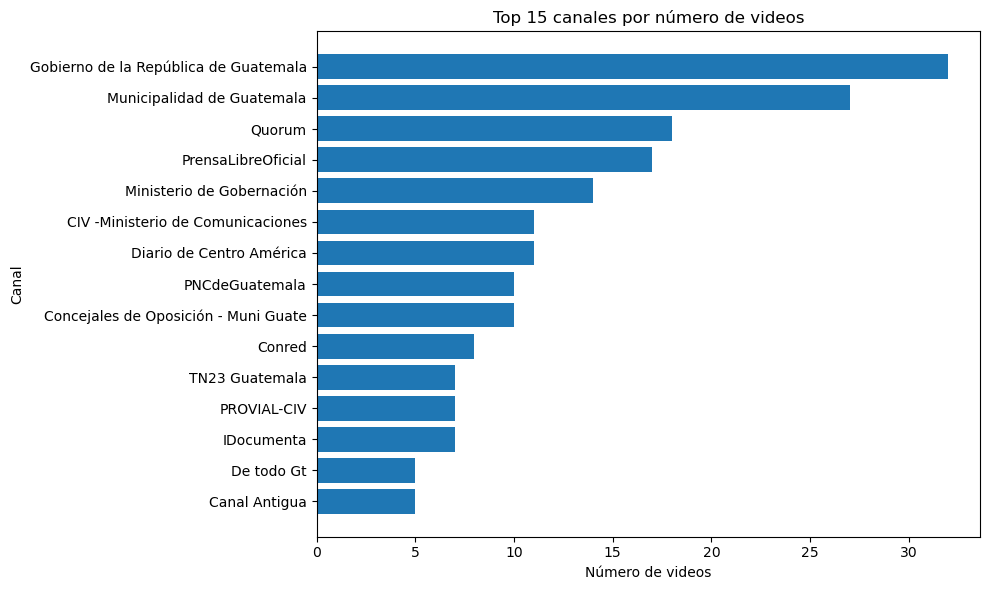

In [52]:
top = videos_por_canal.head(15).sort_values("numero_videos")

plt.figure(figsize=(10, 6))

plt.barh(
    top["channel_name"],
    top["numero_videos"]
)

plt.xlabel("Número de videos")
plt.ylabel("Canal")
plt.title("Top 15 canales por número de videos")

plt.tight_layout()
plt.show()

In [59]:
videos["view_count"].describe()

count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06
Name: view_count, dtype: float64

In [ ]:
videos["view_count"].quantile([0, .25, .5, .75, .90, .95, .99, 1])


In [60]:
top_views = (
    videos[
        [
            "video_id",
            "title",
            "channel_name",
            "view_count"
        ]
    ]
    .sort_values(
        "view_count",
        ascending=False
    )
    .head(15)
)

top_views

,video_id,title,channel_name,view_count
148,THY2YBne3QE,"Los ALUCINANTES autobuses de Guatemala | ""Burras""",Luisito Comunica,8190449
245,n4xHxJPNr78,🚫LOS FAMOSOS BUSES ESMERALDA los mas RÁPIDOS D...,De todo Gt,3152619
113,KkNQhX_kg8A,🇬🇹HISTORIA de GUATEMALA en 17 minutos🇬🇹 - El M...,El Mapa de Sebas,749356
56,Aa7hIDCRh3g,Este BUS me LLEVO a UN PARAISO EN GUATEMALA,De todo Gt,504374
126,NnKpTEfhWjI,✅ ASÍ es una EXHIBICION DE BUSES EN GUATEMALA,De todo Gt,424874
180,_1VIxOLyaUQ,Sonido de trafico y ciudad 💤 ruido de calle pa...,Ambient Sound Explorer,330057
159,VfBrLONPnFM,ME quité el MIEDO de viajar en los buses de GU...,De todo Gt,329489
182,_Lcbi4NCHRA,Tercer Informe General de la República,Gobierno de Guatemala,305269
239,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,304089
176,ZPBiWdHXg20,Piloto de tráiler accidentado en ruta al Atlán...,PrensaLibreOficial,233632


In [9]:
#df.info()
cualitativas=["channel_name", "category","owner_handle", "source_group"]

def tabla_frecuencias(df, columnas=None, incluir_nan=False):

    if columnas is None:
        columnas = df.select_dtypes(include=['object', 'category']).columns

    resultados = {}
    for col in columnas:
        serie = df[col]

        freq_abs = serie.value_counts(dropna=not incluir_nan)
        freq_rel = serie.value_counts(normalize=True, dropna=not incluir_nan)
        freq_acum = freq_rel.cumsum()

        tabla = pd.DataFrame({
            "Frecuencia": freq_abs,
            "Frecuencia Relativa": freq_rel,
            "Frecuencia Acumulada": freq_acum
        })

        resultados[col]=tabla
    return resultados

df_cual=tabla_frecuencias(df, columnas=cualitativas)#Diccionario de Dataframes de variables cualitativas


In [6]:
df_cual["channel_name"]

,Frecuencia,Frecuencia Relativa,Frecuencia Acumulada
channel_name,,,
Gobierno de la República de Guatemala,32,0.109215,0.109215
Municipalidad de Guatemala,27,0.092150,0.201365
Quorum,18,0.061433,0.262799
PrensaLibreOficial,17,0.058020,0.320819
Ministerio de Gobernación,14,0.047782,0.368601
...,...,...,...
Gente de Guate,1,0.003413,0.986348
INFOM TV,1,0.003413,0.989761
Jorge Ramos,1,0.003413,0.993174


In [ ]:
plt.figure(figsize=(8,5))

#plt.bar(["Organismo Judicial", "PNC","MP","P.DD.HH","PGN","BF"],df_cual["INST_DENUN_HECHO"]["Frecuencia"])

plt.title("Institución que atendió el hecho")
plt.xlabel("Institución")
plt.ylabel("Número de casos")

plt.show()

In [7]:
df_cual["category"]

,Frecuencia,Frecuencia Relativa,Frecuencia Acumulada
category,,,
News & Politics,138,0.470990,0.470990
People & Blogs,66,0.225256,0.696246
Entertainment,48,0.163823,0.860068
Education,19,0.064846,0.924915
Travel & Events,8,0.027304,0.952218
Science & Technology,6,0.020478,0.972696
Nonprofits & Activism,3,0.010239,0.982935
Film & Animation,2,0.006826,0.989761
Comedy,1,0.003413,0.993174


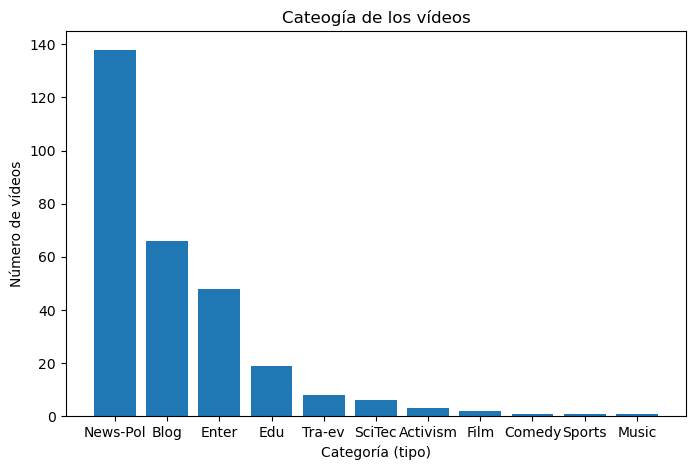

In [29]:
plt.figure(figsize=(8,5))

plt.bar(["News-Pol","Blog","Enter","Edu","Tra-ev","SciTec","Activism","Film","Comedy","Sports", "Music"],df_cual["category"]["Frecuencia"])

plt.title("Cateogía de los vídeos")
plt.xlabel("Categoría (tipo)")
plt.ylabel("Número de vídeos")

plt.show()

In [22]:
df_cual["owner_handle"]

,Frecuencia,Frecuencia Relativa,Frecuencia Acumulada
owner_handle,,,
/@GobiernodelaRepublicadeGuatema,32,0.109215,0.109215
/@MunicipalidaddeGuatemala-1551,27,0.092150,0.201365
/@quorumgt,18,0.061433,0.262799
/@PrensaLibreOficial,17,0.058020,0.320819
/@mingobguate,14,0.047782,0.368601
...,...,...,...
/@GentedeGuate,1,0.003413,0.986348
/@tvinfomguatemala,1,0.003413,0.989761
/@jorgeramos-asiveolascosas,1,0.003413,0.993174


In [10]:
df_cual["source_group"]

,Frecuencia,Frecuencia Relativa,Frecuencia Acumulada
source_group,,,
topic,177,0.604096,0.604096
official_gov,105,0.358362,0.962457
channel,11,0.037543,1.000000


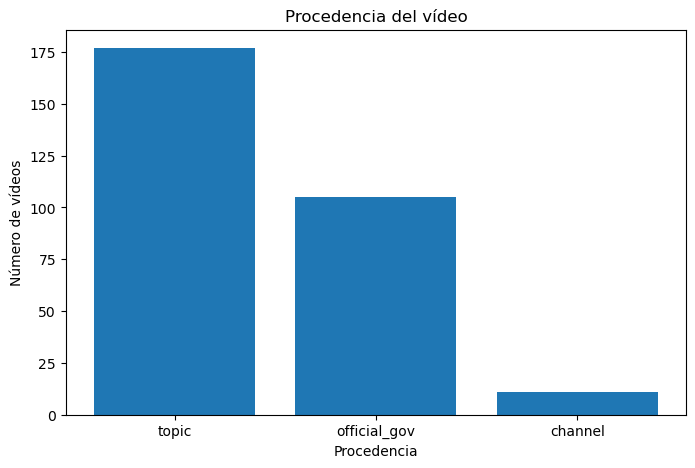

In [30]:
plt.figure(figsize=(8,5))

plt.bar(["topic", "official_gov", "channel"],df_cual["source_group"]["Frecuencia"])

plt.title("Procedencia del vídeo")
plt.xlabel("Procedencia")
plt.ylabel("Número de vídeos")

plt.show()

In [31]:
df.describe()

,view_count
count,2.930000e+02
mean,6.043009e+04
std,5.157983e+05
min,2.000000e+00
25%,2.150000e+02
50%,1.175000e+03
75%,7.465000e+03
max,8.190449e+06


In [68]:
consultas = (
    videos["source_query"]
    .value_counts()
)

consultas

source_query
Municipalidad de Guatemala                20
Gobierno de Guatemala                     18
@GobiernodelaRepublicadeGuatema           18
@GobiernodeGuatemala                      17
guatemala noticias                        16
Ministerio de Comunicaciones Guatemala    16
@MunicipalidaddeGuatemala-1551            16
Gobierno de la República de Guatemala     15
PMT Guatemala                             15
Conred Guatemala                          15
Provial Guatemala                         13
guatemala trafico                         13
guatemala transporte                      13
Policia Nacional Civil Guatemala          13
guatemala lluvias                         12
guatemala politica                        12
guatemala seguridad                       12
Ministerio de Gobernacion Guatemala       12
@quorumgt                                 12
@quorumgt/videos                          11
Quorum GT                                  4
Name: count, dtype: int64

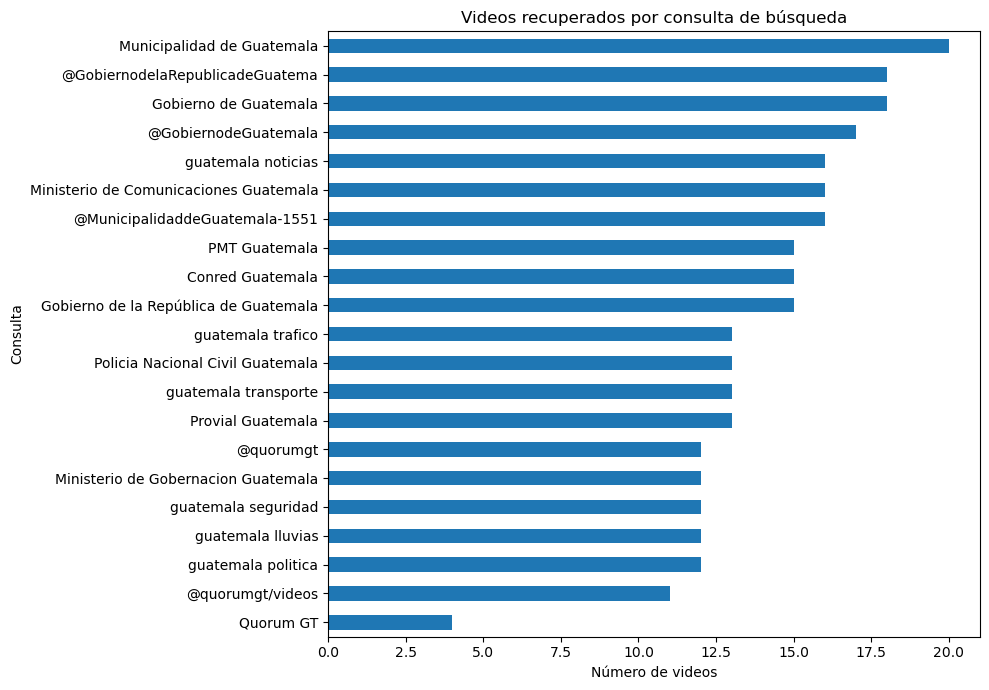

In [69]:
plt.figure(figsize=(10, 7))

consultas.sort_values().plot(
    kind="barh"
)

plt.xlabel("Número de videos")
plt.ylabel("Consulta")
plt.title("Videos recuperados por consulta de búsqueda")

plt.tight_layout()
plt.show()

# Análisis de Comentarios

In [58]:
comments.head(2)

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los teng...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tu...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN


In [57]:
comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   video_id           406 non-null    object 
 1   comment_id         406 non-null    object 
 2   video_title        406 non-null    object 
 3   channel_name       406 non-null    object 
 4   channel_id         406 non-null    object 
 5   author_name        406 non-null    object 
 6   author_channel_id  406 non-null    object 
 7   text               406 non-null    object 
 8   source_query       406 non-null    object 
 9   source_group       406 non-null    object 
 10  dataset_sources    406 non-null    object 
 11  author_handle      406 non-null    object 
 12  published_text     406 non-null    object 
 13  like_count_text    406 non-null    object 
 14  reply_count        406 non-null    int64  
 15  is_pinned          406 non-null    bool   
 16  viewer_rating      0 non-n

In [45]:
#De lo anterior se elimina viewer_rating porque no tiene valor alguno
dfc = dfc.drop(columns=["viewer_rating"], errors="ignore") 

In [46]:
print("Comentarios duplicados:",
      dfc["comment_id"].duplicated().sum())

Comentarios duplicados: 0


In [53]:
participacion_video = (
    comments.groupby(
        ["video_id", "video_title", "channel_name"]
    )
    .agg(
        comentarios=("comment_id", "nunique"),
        autores_unicos=("author_channel_id", "nunique"),
        respuestas=("reply_count", "sum")
    )
    .reset_index()
    .sort_values(
        "comentarios",
        ascending=False
    )
)

participacion_video

,video_id,video_title,channel_name,comentarios,autores_unicos,respuestas
14,n8iP75gIpmw,Qué rico come tu diputado,Quorum,161,128,3
12,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,50,49,0
2,6W4u8sGEnGM,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,45,32,11
13,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,25,16
5,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,25,19,4
4,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,25,18,13
17,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,Quorum,16,16,0
0,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados ...,Noti7,14,13,1
15,ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,12,10,1
11,is3Mk5oC19g,Capturan a ladrón que había quedado grabado mi...,TN23 Guatemala,7,7,1


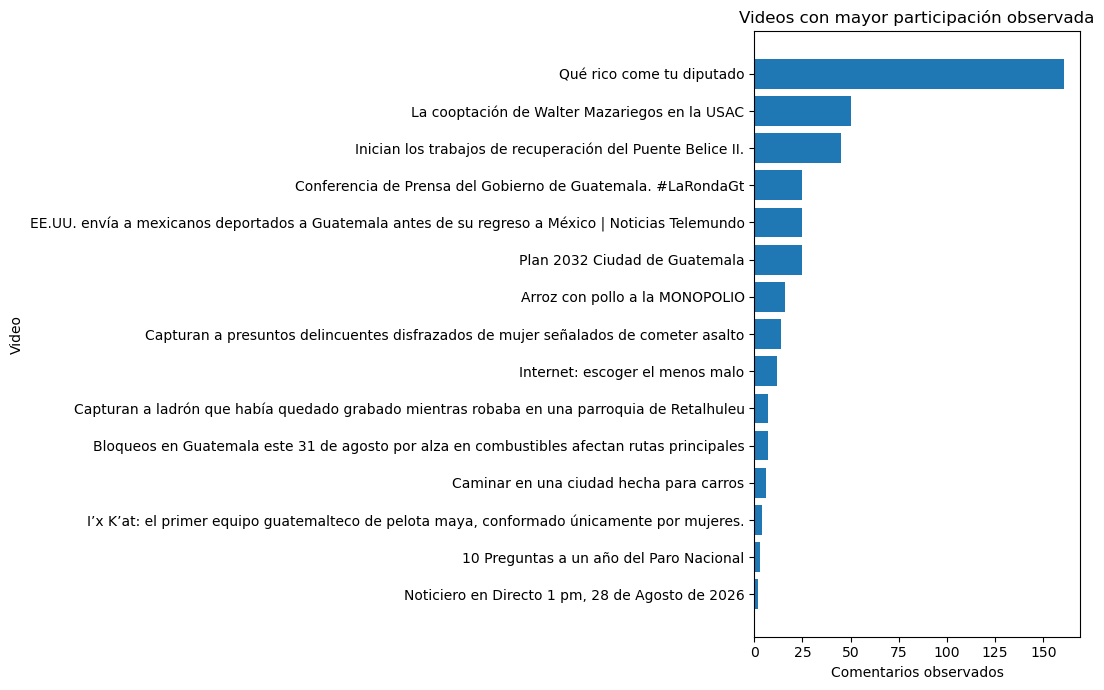

In [54]:
top = (
    participacion_video
    .head(15)
    .sort_values("comentarios")
)

plt.figure(figsize=(11, 7))

plt.barh(
    top["video_title"],
    top["comentarios"]
)

plt.xlabel("Comentarios observados")
plt.ylabel("Video")
plt.title("Videos con mayor participación observada")

plt.tight_layout()
plt.show()

In [55]:
participacion_canal = (
    comments.groupby(
        ["channel_id", "channel_name"]
    )
    .agg(
        comentarios=("comment_id", "nunique"),
        autores_unicos=("author_channel_id", "nunique"),
        videos=("video_id", "nunique"),
        respuestas=("reply_count", "sum")
    )
    .reset_index()
    .sort_values(
        "comentarios",
        ascending=False
    )
)

participacion_canal

,channel_id,channel_name,comentarios,autores_unicos,videos,respuestas
1,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,256,214,11,4
0,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,70,50,2,15
3,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,25,18,1,13
5,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,25,25,1,16
4,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,14,13,1,1
2,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,7,7,1,1
7,UCt5Dw7ePnn0AqPqRF8Xpjkw,TN23 Guatemala,7,7,1,1
6,UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,2,2,1,0


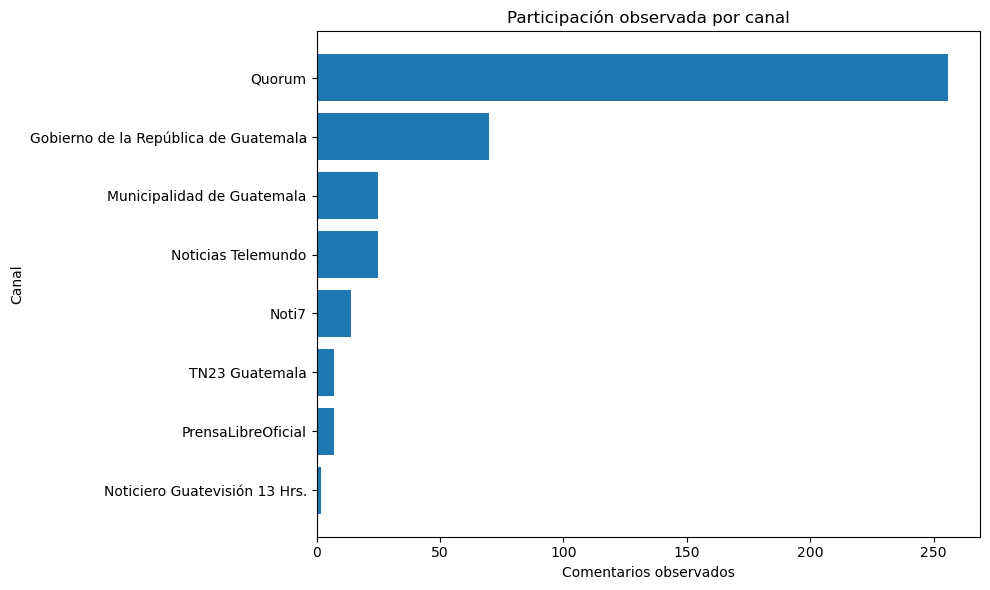

In [56]:
plt.figure(figsize=(10, 6))

datos = (
    participacion_canal
    .sort_values("comentarios")
)

plt.barh(
    datos["channel_name"],
    datos["comentarios"]
)

plt.xlabel("Comentarios observados")
plt.ylabel("Canal")
plt.title("Participación observada por canal")

plt.tight_layout()
plt.show()

In [62]:
comments["like_count"] = pd.to_numeric(
    comments["like_count_text"],
    errors="coerce"
).fillna(0)

In [63]:
comments["like_count"].describe()

count    406.000000
mean       5.726601
std       30.661298
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max      405.000000
Name: like_count, dtype: float64

In [64]:
top_likes = (
    comments[
        [
            "author_name",
            "text",
            "video_title",
            "like_count"
        ]
    ]
    .sort_values(
        "like_count",
        ascending=False
    )
    .head(20)
)

top_likes

,author_name,text,video_title,like_count
299,@zetag,Quiero vivir en esa Guatemala :v,Plan 2032 Ciudad de Guatemala,405.0
193,@elenaluarca9377,Que bueno que Guatemala sea una cuidad bonita ...,Plan 2032 Ciudad de Guatemala,329.0
338,@samuelaguilar529,Me encantaría vivir por un tiempo en Guatemala...,Plan 2032 Ciudad de Guatemala,211.0
124,@TheAlexX_C,"Que bella es la Ciudad de Guatemala, unica en ...",Plan 2032 Ciudad de Guatemala,191.0
184,@sabinamarinaguerra3248,Se ve moderna Y bella la ciudad de Guatemala ....,Plan 2032 Ciudad de Guatemala,113.0
388,@maynorcalel1442,Primero Dios,Plan 2032 Ciudad de Guatemala,79.0
280,@jhonymanuel9891,Wow una ciudad de futuro,Plan 2032 Ciudad de Guatemala,70.0
402,@WalksandSuch,muy padre. saludos desde mexico.,Plan 2032 Ciudad de Guatemala,68.0
195,@rolandojuchuna484,Sería muy bueno construir el tren a nivel dep...,Plan 2032 Ciudad de Guatemala,52.0
331,@carlosoliva9249,Impresionante 👏🏻👏🏻 la ciudad de Guatemala siem...,Plan 2032 Ciudad de Guatemala,45.0


In [65]:
comments["reply_count"].describe()

count    406.000000
mean       0.125616
std        0.580748
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        7.000000
Name: reply_count, dtype: float64

In [66]:
comments["reply_count"].value_counts().sort_index()

reply_count
0    376
1     21
2      3
3      4
5      1
7      1
Name: count, dtype: int64

In [67]:
print(
    "Total de respuestas:",
    comments["reply_count"].sum()
)

print(
    "Comentarios con respuestas:",
    (comments["reply_count"] > 0).sum()
)

Total de respuestas: 51
Comentarios con respuestas: 30
